In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.datasets import fashion_mnist
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

In [ ]:
(X_train, y_train), (X_test, y_test) = fashion_mnist.load_data()

In [ ]:
print("Training Images Shape :", X_train.shape)
print("Training Labels Shape :", y_train.shape)
print("Testing Images Shape  :", X_test.shape)
print("Testing Labels Shape  :", y_test.shape)

Training Images Shape : (60000, 28, 28)
Training Labels Shape : (60000,)
Testing Images Shape  : (10000, 28, 28)
Testing Labels Shape  : (10000,)


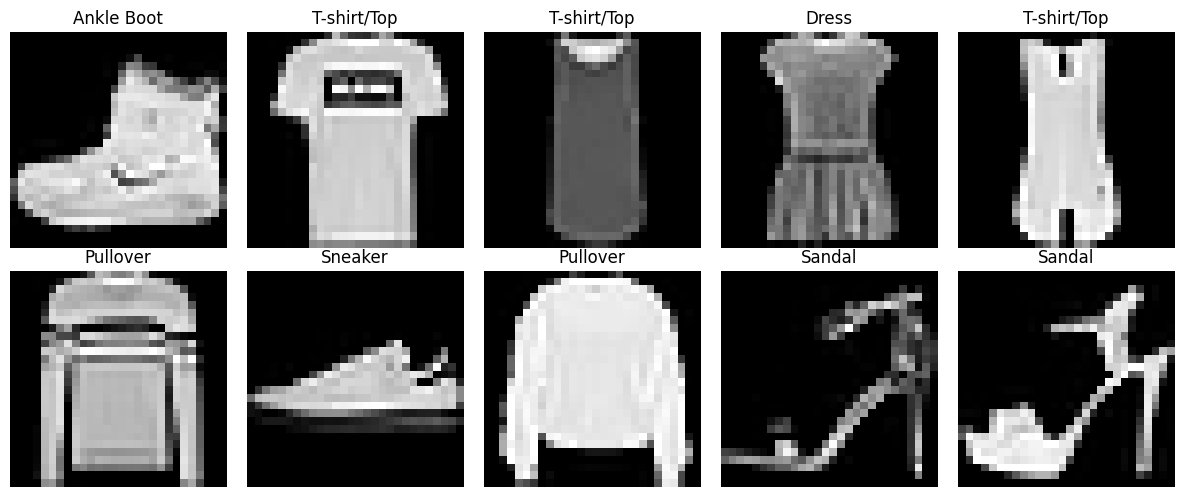

In [ ]:
class_names = [
    "T-shirt/Top",
    "Trouser",
    "Pullover",
    "Dress",
    "Coat",
    "Sandal",
    "Shirt",
    "Sneaker",
    "Bag",
    "Ankle Boot"
]

plt.figure(figsize=(12,5))

for i in range(10):
    plt.subplot(2,5,i+1)
    plt.imshow(X_train[i], cmap="gray")
    plt.title(class_names[y_train[i]])
    plt.axis("off")

plt.tight_layout()
plt.show()

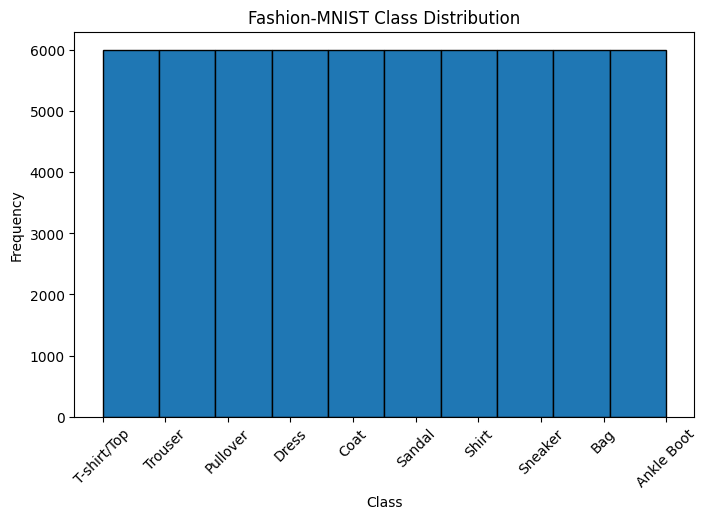

In [ ]:
plt.figure(figsize=(8,5))

plt.hist(y_train, bins=10, edgecolor='black')

plt.xticks(range(10), class_names, rotation=45)

plt.xlabel("Class")
plt.ylabel("Frequency")
plt.title("Fashion-MNIST Class Distribution")

plt.show()

In [ ]:
# Flatten images
X_train = X_train.reshape(X_train.shape[0], 784)
X_test = X_test.reshape(X_test.shape[0], 784)

# Normalize pixel values
X_train = X_train.astype("float32") / 255.0
X_test = X_test.astype("float32") / 255.0

In [ ]:
from tensorflow.keras.utils import to_categorical

y_train_cat = to_categorical(y_train, 10)
y_test_cat = to_categorical(y_test, 10)

In [ ]:
model = Sequential([
    Dense(128, activation='relu', input_shape=(784,)),
    Dense(64, activation='relu'),
    Dense(10, activation='softmax')
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 109,386 (427.29 KB)

 Trainable params: 109,386 (427.29 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [ ]:
print(X_train.shape)
print(X_test.shape)

(60000, 784)
(10000, 784)


In [ ]:
print(X_train.shape)
print(y_train_cat.shape)

(60000, 784)
(60000, 10)


In [ ]:
history = model.fit(
    X_train,
    y_train_cat,

    epochs=20,
    batch_size=32,
    verbose=1
)

Epoch 1/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 3ms/step - accuracy: 0.8255 - loss: 0.4907
Epoch 2/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.8664 - loss: 0.3684
Epoch 3/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 9s 3ms/step - accuracy: 0.8772 - loss: 0.3352
Epoch 4/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.8856 - loss: 0.3108
Epoch 5/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.8926 - loss: 0.2911
Epoch 6/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.8949 - loss: 0.2798
Epoch 7/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9003 - loss: 0.2672
Epoch 8/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9035 - loss: 0.2548
Epoch 9/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9072 - loss: 0.2475
Epoch 10/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9103 - loss: 0.2374
Epoch 11/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9128 - loss: 0.2279
Epoch 12/20
1875/1875 ━━━━━━━━

In [ ]:
y_pred_prob = model.predict(X_test)
y_pred = np.argmax(y_pred_prob, axis=1)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step


In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

In [ ]:
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average='weighted')
recall = recall_score(y_test, y_pred, average='weighted')
f1 = f1_score(y_test, y_pred, average='weighted')

print("Accuracy :", accuracy)
print("Precision:", precision)
print("Recall   :", recall)
print("F1-score :", f1)

Accuracy : 0.8896
Precision: 0.8919596471246576
Recall   : 0.8896
F1-score : 0.8900646182175759


In [ ]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.84      0.83      0.84      1000
           1       0.99      0.97      0.98      1000
           2       0.85      0.75      0.80      1000
           3       0.91      0.88      0.89      1000
           4       0.78      0.86      0.82      1000
           5       0.98      0.97      0.98      1000
           6       0.69      0.74      0.71      1000
           7       0.92      0.97      0.95      1000
           8       0.97      0.98      0.98      1000
           9       0.98      0.94      0.96      1000

    accuracy                           0.89     10000
   macro avg       0.89      0.89      0.89     10000
weighted avg       0.89      0.89      0.89     10000



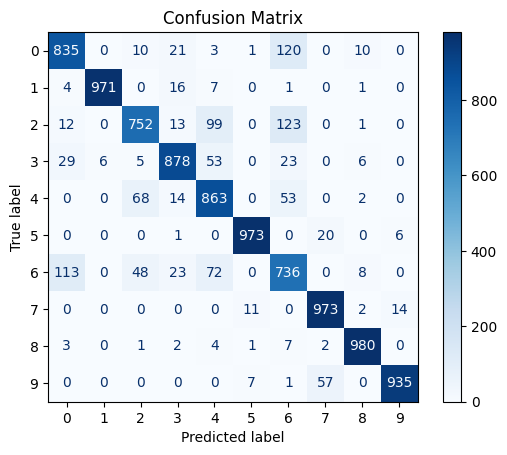

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Create confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Display it
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap="Blues")
plt.title("Confusion Matrix")
plt.show()

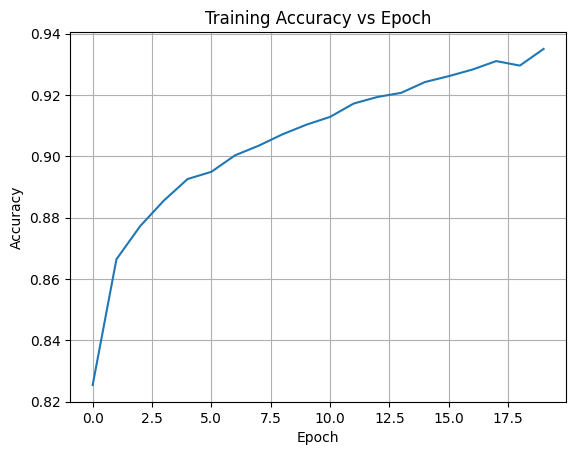

In [ ]:
import matplotlib.pyplot as plt

plt.plot(history.history['accuracy'])
plt.title("Training Accuracy vs Epoch")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.grid(True)
plt.show()

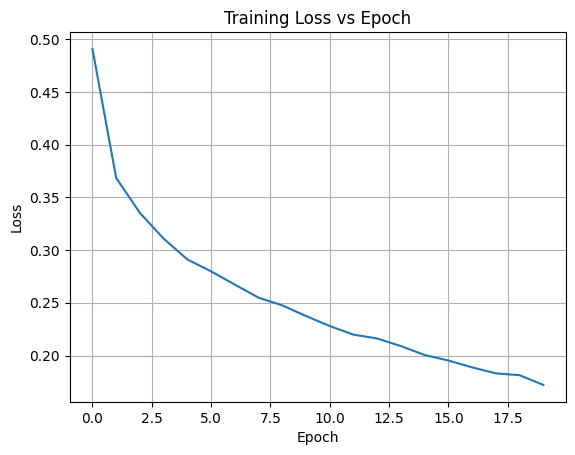

In [ ]:
plt.plot(history.history['loss'])
plt.title("Training Loss vs Epoch")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.grid(True)
plt.show()

In [ ]:
from scikeras.wrappers import KerasClassifier
from sklearn.model_selection import RandomizedSearchCV
from tensorflow.keras.optimizers import Adam, SGD, RMSprop

In [ ]:
def build_model(hidden_layers=2,
                neurons=128,
                learning_rate=0.001,
                optimizer="adam",
                activation="relu"):

    model = Sequential()

    model.add(Dense(neurons,
                    activation=activation,
                    input_shape=(784,)))

    for i in range(hidden_layers - 1):
        model.add(Dense(neurons, activation=activation))

    model.add(Dense(10, activation="softmax"))

    if optimizer == "adam":
        opt = Adam(learning_rate=learning_rate)
    elif optimizer == "sgd":
        opt = SGD(learning_rate=learning_rate)
    else:
        opt = RMSprop(learning_rate=learning_rate)

    model.compile(
        optimizer=opt,
        loss="categorical_crossentropy",
        metrics=["accuracy"]
    )

    return model

In [ ]:
clf = KerasClassifier(
    model=build_model,
    verbose=0
)

In [ ]:
from scikeras.wrappers import KerasClassifier

keras_clf = KerasClassifier(
    model=build_model,
    verbose=0
)

In [ ]:
param_dist = {
    "model__hidden_layers": [1, 2, 3],
    "model__hidden_neurons": [32, 64, 128],
    "model__learning_rate": [0.0001, 0.001, 0.01],
    "model__activation": ["relu", "tanh"],
    "model__dropout_rate": [0.0, 0.2],
    "model__optimizer_name": ["adam", "sgd"],
    "batch_size": [32, 64],
    "epochs": [5, 10]
}
random_search = RandomizedSearchCV(
    estimator=keras_clf,
    param_distributions=param_dist,
    n_iter=10,
    cv=5,
    random_state=42,
    n_jobs=1,
    error_score="raise"
)


In [ ]:
print("Best Parameters:")
print(random_search.best_params_)

print("Best Cross Validation Accuracy:")
print(random_search.best_score_)

In [ ]:
best = random_search.best_params_

optimized_model = build_model(
    hidden_layers=best["model__hidden_layers"],
    neurons=best["model__neurons"],
    learning_rate=best["model__learning_rate"],
    optimizer=best["model__optimizer"],
    activation=best["model__activation"]
)

optimized_model.fit(
    X_train,
    y_train_cat,
    epochs=best["epochs"],
    batch_size=best["batch_size"],
    verbose=1
)

In [ ]:
y_pred_prob = optimized_model.predict(X_test)
y_pred = np.argmax(y_pred_prob, axis=1)

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average="weighted")
recall = recall_score(y_test, y_pred, average="weighted")
f1 = f1_score(y_test, y_pred, average="weighted")

print("\nOptimized Model Performance")
print("Accuracy :", accuracy)
print("Precision:", precision)
print("Recall   :", recall)
print("F1-score :", f1)

In [ ]:
print("\nComparison")

print("Baseline Accuracy :", history.history["accuracy"][-1])
print("Optimized Accuracy:", accuracy)

if accuracy > history.history["accuracy"][-1]:
    print("The optimized model performs better than the baseline model.")
else:
    print("The baseline model performs similarly or better.")

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step
Predictions:
[0. 0.] -> 0.4093
[0. 1.] -> 0.7751
[1. 0.] -> 0.4093
[1. 1.] -> 0.4093

Accuracy: 0.75


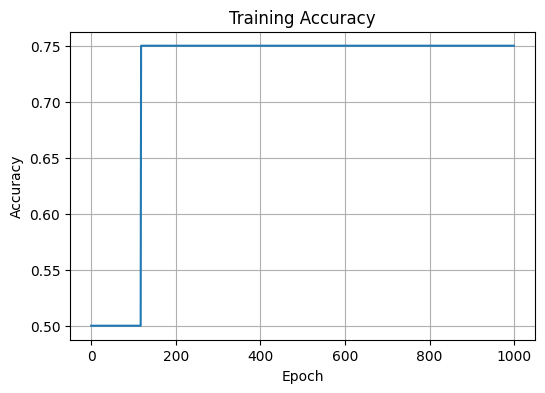

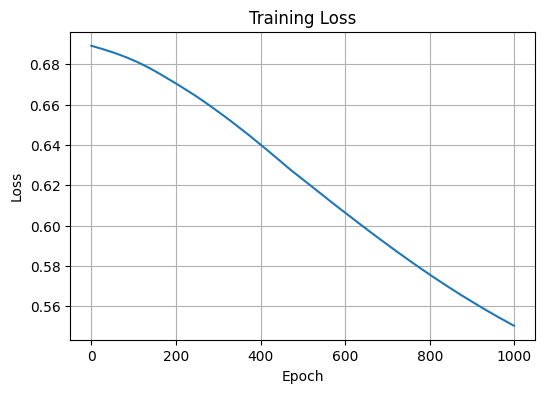

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

# XOR Dataset
X = np.array([
    [0,0],
    [0,1],
    [1,0],
    [1,1]
], dtype=float)

y = np.array([0,1,1,0], dtype=float)

# Build MLP
model = Sequential([
    Dense(2, activation='relu', input_shape=(2,)),
    Dense(1, activation='sigmoid')
])

model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

history = model.fit(
    X,
    y,
    epochs=1000,
    verbose=0
)

# Predictions
pred = model.predict(X)

print("Predictions:")
for i in range(len(X)):
    print(f"{X[i]} -> {pred[i][0]:.4f}")

# Evaluate
loss, acc = model.evaluate(X, y, verbose=0)
print("\nAccuracy:", acc)

# Plot Accuracy
plt.figure(figsize=(6,4))
plt.plot(history.history['accuracy'])
plt.title("Training Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.grid(True)
plt.show()

# Plot Loss
plt.figure(figsize=(6,4))
plt.plot(history.history['loss'])
plt.title("Training Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.grid(True)
plt.show()

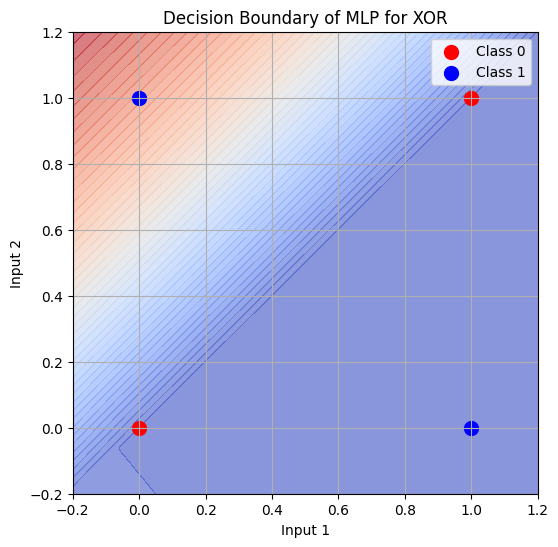

In [2]:
# Decision Boundary

xx, yy = np.meshgrid(
    np.linspace(-0.2,1.2,100),
    np.linspace(-0.2,1.2,100)
)

grid = np.c_[xx.ravel(), yy.ravel()]
Z = model.predict(grid, verbose=0)
Z = Z.reshape(xx.shape)

plt.figure(figsize=(6,6))
plt.contourf(xx, yy, Z, levels=50, cmap='coolwarm', alpha=0.6)

plt.scatter(X[y==0][:,0], X[y==0][:,1],
            color='red', label='Class 0', s=100)

plt.scatter(X[y==1][:,0], X[y==1][:,1],
            color='blue', label='Class 1', s=100)

plt.title("Decision Boundary of MLP for XOR")
plt.xlabel("Input 1")
plt.ylabel("Input 2")
plt.legend()
plt.grid(True)
plt.show()